In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from collections import defaultdict
import matplotlib
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import linregress
from sklearn.metrics.pairwise import cosine_similarity
import warnings
import pickle as pkl
import os
import math
warnings.simplefilter("ignore")

In [2]:
from mtu_plots import graph_metrics_and_models, transform_relative_to_ideal
from mtu_utils import (
    get_inter_user_metrics,
    get_intra_user_metrics,
    get_sim_users_pairs,
)
print(matplotlib.__version__)

3.6.3


In [3]:
DEBUG = True

In [4]:
# graphing
plt.style.use('seaborn-whitegrid')
plt.rcParams.update({'font.size': 14})

# readable legend keys
id_to_readable = {
    "ideal": "Ideal",
    "content": "Content Filtering",
    "condent_reduced": "Reduced Attrs Content Filtering",
    "pop": "Popularity",
    "mf" : "Matrix Factorization",
    "sf": "Social Filtering", 
    "random": "Random"
}

In [5]:
folder_paths = ["2_metrics_results\\results_2"]

In [6]:
final_results = defaultdict(lambda: defaultdict(list))
for folder_path in folder_paths:
    filepath = os.path.join(folder_path, "sim_results.pkl")
    results = pkl.load(open(filepath, "rb"))
    for metric_name, v in results.items():
        for model_name, metric_vals in v.items():
            final_results[metric_name][model_name] += np.array(metric_vals).tolist()

In [7]:
user_prefs = np.array(final_results['user_prefs']['all'])
item_attrs = np.array(final_results['item_attrs']['all'])

In [8]:
interactions = dict()
for mo in id_to_readable.keys():
    interactions[mo] = np.array(final_results['interaction_history'][mo])
    interactions[mo] = np.transpose(interactions[mo].reshape(interactions[mo].shape[:-1]), axes=[0,2,1])

In [9]:
colors = dict()
colors['condent_reduced'] = 'tab:green'
colors['pop'] = 'tab:red'
colors['sf'] = 'tab:brown'
colors['content'] = 'tab:orange'
colors['mf'] = 'tab:purple'
colors['ideal'] = 'tab:blue'
colors['random'] = 'tab:pink'

# Métricas

In [10]:
inter_user_dis = dict()
inter_user_div = dict()
for mo in interactions.keys():
    inter_user_dis[mo] = []
    inter_user_div[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        re1 = []
        for j in range(interactions[mo].shape[2]):
            m, v = get_inter_user_metrics(item_attrs[i], interactions[mo][i][:,:j])
            re.append(m if not math.isnan(m) else 0.)
            re1.append(v if not math.isnan(v) else 0.)
        inter_user_dis[mo].append(re)
        inter_user_div[mo].append(re1)
    inter_user_dis[mo] = np.array(inter_user_dis[mo])
    inter_user_div[mo] = np.array(inter_user_div[mo])

In [11]:
inter_user_dis['content'].shape

(6, 200)

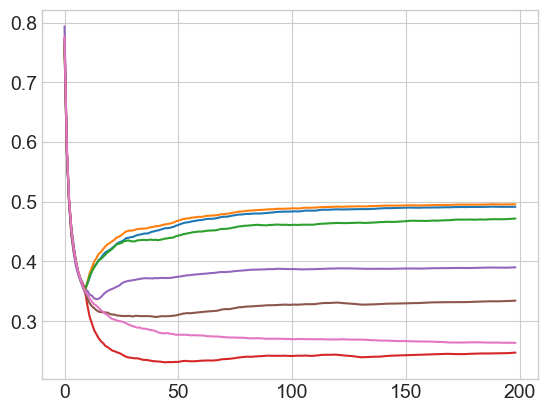

In [12]:
for mo in interactions.keys():
    values = gaussian_filter1d(inter_user_dis[mo].mean(axis=0), sigma=0.1)
    plt.plot(values[1:], label=mo)
plt.show()

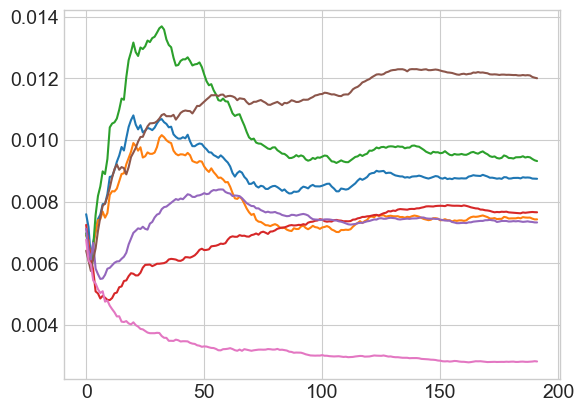

In [13]:
for mo in interactions.keys():
    values = gaussian_filter1d(inter_user_div[mo].mean(axis=0), sigma=0.1)
    plt.plot(values[8:], label=mo)
plt.show()

In [14]:
intra_user_dis = dict()
intra_user_div = dict()
for mo in interactions.keys():
    intra_user_dis[mo] = []
    intra_user_div[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        re1 = []
        for j in range(interactions[mo].shape[2]):
            m, _, v = get_intra_user_metrics(item_attrs[i], interactions[mo][i][:,:j])
            re.append(m if not math.isnan(m) else 0.)
            re1.append(v if not math.isnan(v) else 0.)
        intra_user_dis[mo].append(re)
        intra_user_div[mo].append(re1)
    intra_user_dis[mo] = np.array(intra_user_dis[mo])
    intra_user_div[mo] = np.array(intra_user_div[mo])

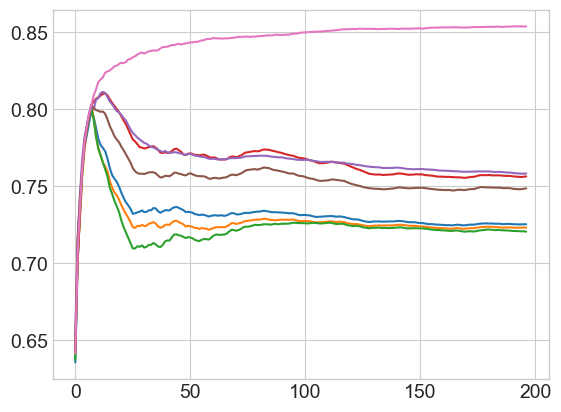

In [15]:
for mo in interactions.keys():
    values = gaussian_filter1d(intra_user_dis[mo].mean(axis=0), sigma=0.1)
    plt.plot(values[3:], label=mo)
plt.show()

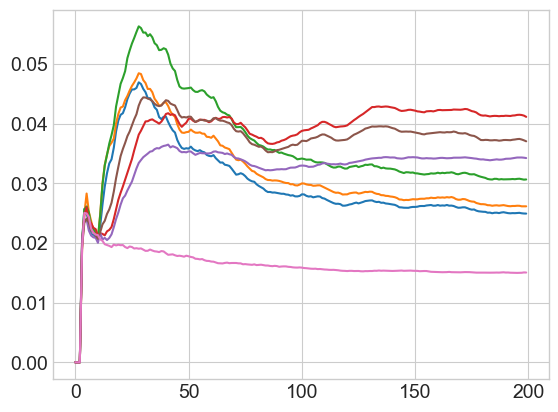

In [16]:
for mo in interactions.keys():
    values = gaussian_filter1d(intra_user_div[mo].mean(axis=0), sigma=0.1)
    plt.plot(values[0:], label=mo)
plt.show()

In [17]:
dispersion_metric_2 = dict()
for mo in interactions.keys():
    dispersion_metric_2[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = [0.]
        distances = np.zeros((interactions[mo].shape[1], 0))
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        for j in range(1, user_iter_attrs.shape[1]):
            new_distances = np.linalg.norm(np.array([user_iter_attrs[k,:j] - user_iter_attrs[k,j] for k in range(user_iter_attrs.shape[0])]), axis=2)
            distances = np.hstack([distances, new_distances])
            re.append(distances.var(axis=1).mean())
        dispersion_metric_2[mo].append(re)
    dispersion_metric_2[mo] = np.array(dispersion_metric_2[mo])

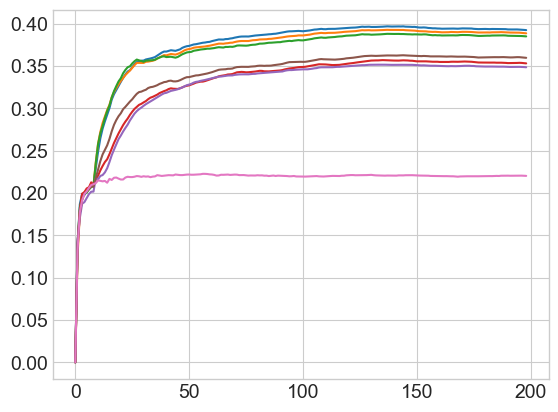

In [18]:
for mo in interactions.keys():
    values = gaussian_filter1d(dispersion_metric_2[mo].mean(axis=0), sigma=0.1)
    plt.plot(values[1:], label=mo)
plt.show()

In [19]:
ideal_dispersion_metric_2 = dispersion_metric_2['ideal']
dispersion_metric_2_relative = {mo: dispersion_metric_2[mo] - ideal_dispersion_metric_2 for mo in dispersion_metric_2.keys()}

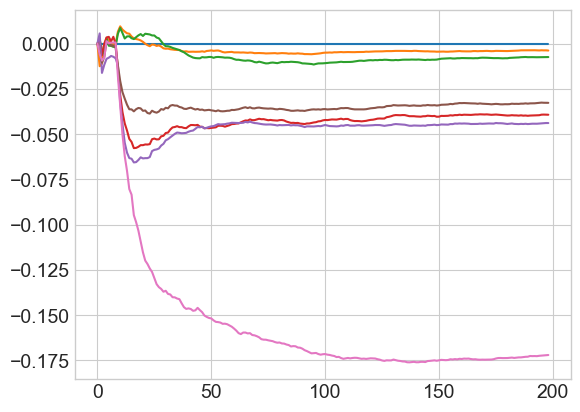

In [20]:
for mo in interactions.keys():
    values = gaussian_filter1d(dispersion_metric_2_relative[mo].mean(axis=0), sigma=0.1)
    plt.plot(values[1:], label=mo)
plt.show()

In [21]:
dispersion_metric_3 = dict()
for mo in interactions.keys():
    dispersion_metric_3[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            diff_vectors = np.zeros((0, mean_user_attrs.shape[1]), dtype=float)
            for k in range(1, mean_user_attrs.shape[0]):
                diff = mean_user_attrs[:k] - mean_user_attrs[k]
                diff_vectors = np.concatenate((diff_vectors, diff))
            distances = np.linalg.norm(diff_vectors, axis=1)
            re.append(distances.var())
        dispersion_metric_3[mo].append(re)
    dispersion_metric_3[mo] = np.array(dispersion_metric_3[mo])

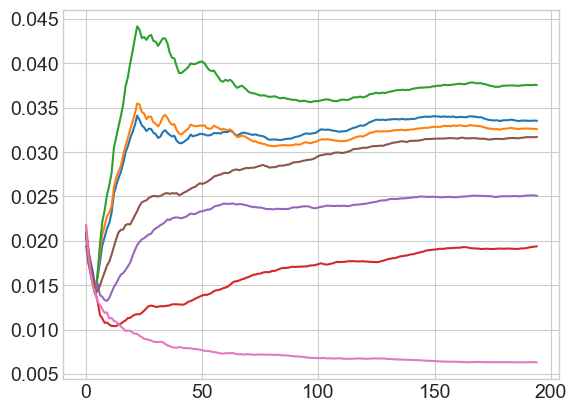

In [22]:
for mo in interactions.keys():
    values = gaussian_filter1d(dispersion_metric_3[mo].mean(axis=0), sigma=0.1)
    plt.plot(values[5:], label=mo)
plt.show()

In [23]:
fbe = dict()
homog = dict()
for mo in interactions.keys():
    fbe[mo] = []
    homog[mo] = []
    for i in range(interactions[mo].shape[0]):
        fbe[mo].append(dispersion_metric_3[mo][i] / dispersion_metric_2[mo][i])
        homog[mo].append(1. / (dispersion_metric_3[mo][i]**2 + dispersion_metric_2[mo][i]**2)**0.5)
    fbe[mo] = np.array(fbe[mo])
    homog[mo] = np.array(homog[mo])

In [24]:
ideal_fbe = fbe['ideal']
fbe_relative = {mo: fbe[mo] - ideal_fbe for mo in fbe.keys()}
ideal_homog = homog['ideal']
homog_relative = {mo: homog[mo] - ideal_homog for mo in homog.keys()}

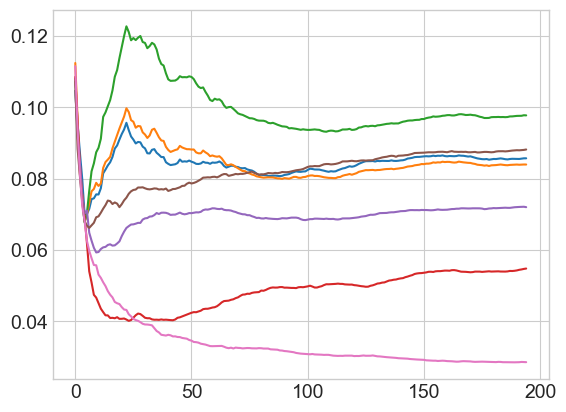

In [25]:
for mo in interactions.keys():
    values = gaussian_filter1d(fbe[mo].mean(axis=0), sigma=0.1)
    plt.plot(values[5:], label=mo)
plt.show()

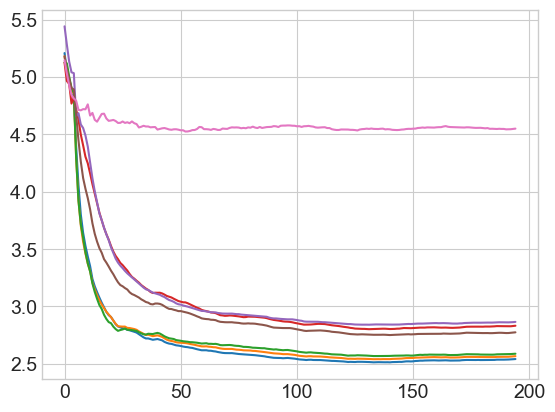

In [26]:
for mo in interactions.keys():
    values = gaussian_filter1d(homog[mo].mean(axis=0), sigma=0.1)
    plt.plot(values[5:], label=mo)
plt.show()

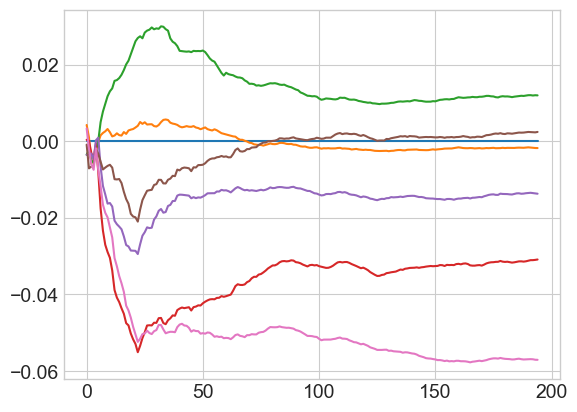

In [27]:
for mo in interactions.keys():
    values = gaussian_filter1d(fbe_relative[mo].mean(axis=0), sigma=0.1)
    plt.plot(values[5:], label=mo)
plt.show()

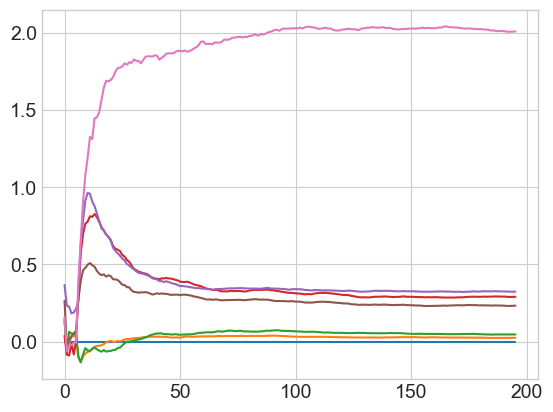

In [28]:
for mo in interactions.keys():
    values = gaussian_filter1d(homog_relative[mo].mean(axis=0), sigma=0.1)
    plt.plot(values[4:], label=mo)
plt.show()

In [29]:
dispersion_metric_4 = dict()
for mo in interactions.keys():
    dispersion_metric_4[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            diff_vectors = np.zeros((0, mean_user_attrs.shape[1]), dtype=float)
            nearest_users = get_sim_users_pairs(mean_user_attrs)
            for p in nearest_users:
                diff = mean_user_attrs[p[0]] - mean_user_attrs[p[1]]
                diff_vectors = np.append(diff_vectors, [diff], axis=0)
            distances = np.linalg.norm(diff_vectors, axis=1)
            re.append(distances.mean())
        dispersion_metric_4[mo].append(re)
    dispersion_metric_4[mo] = np.array(dispersion_metric_4[mo])

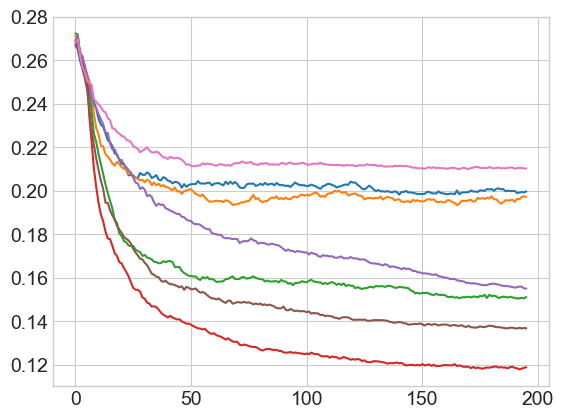

In [30]:
for mo in interactions.keys():
    values = gaussian_filter1d(dispersion_metric_4[mo].mean(axis=0), sigma=0.1)
    plt.plot(values[4:], label=mo)
plt.show()

In [31]:
dispersion_metric_5 = dict()
for mo in interactions.keys():
    dispersion_metric_5[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            diff_vectors = np.zeros((0, mean_user_attrs.shape[1]), dtype=float)
            real_diff_vectors = np.zeros((0, mean_user_attrs.shape[1]), dtype=float)
            nearest_users = get_sim_users_pairs(mean_user_attrs)
            for p in nearest_users:
                diff = mean_user_attrs[p[0]] - mean_user_attrs[p[1]]
                real_diff = user_prefs[i][p[0]] - user_prefs[i][p[1]]
                diff_vectors = np.append(diff_vectors, [diff], axis=0)
                real_diff_vectors = np.append(real_diff_vectors, [real_diff], axis=0)
            distances = np.linalg.norm(real_diff_vectors, axis=1) - np.linalg.norm(diff_vectors, axis=1)
            re.append(distances.mean())
        dispersion_metric_5[mo].append(re)
    dispersion_metric_5[mo] = np.array(dispersion_metric_5[mo])

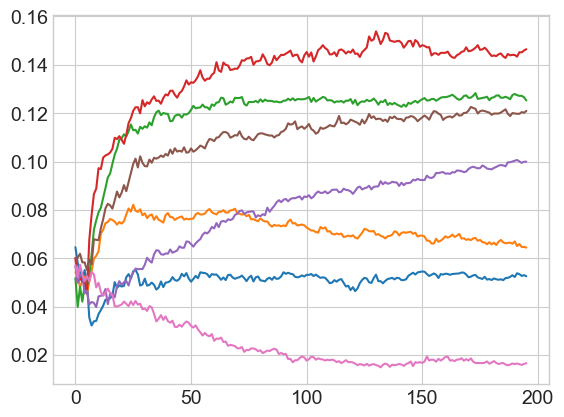

In [32]:
for mo in interactions.keys():
    values = gaussian_filter1d(dispersion_metric_5[mo].mean(axis=0), sigma=0.1)
    plt.plot(values[4:], label=mo)
plt.show()

In [33]:
dispersion_metric_6 = dict()
for mo in interactions.keys():
    dispersion_metric_6[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        real_nearest_users = get_sim_users_pairs(user_prefs[i])
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            diff_vectors = np.zeros((0, mean_user_attrs.shape[1]), dtype=float)
            real_diff_vectors = np.zeros((0, mean_user_attrs.shape[1]), dtype=float)
            for p in real_nearest_users:
                diff = mean_user_attrs[p[0]] - mean_user_attrs[p[1]]
                real_diff = user_prefs[i][p[0]] - user_prefs[i][p[1]]
                diff_vectors = np.append(diff_vectors, [diff], axis=0)
                real_diff_vectors = np.append(real_diff_vectors, [real_diff], axis=0)
            distances = np.linalg.norm(diff_vectors, axis=1) - np.linalg.norm(real_diff_vectors, axis=1)
            re.append(distances.mean())
        dispersion_metric_6[mo].append(re)
    dispersion_metric_6[mo] = np.array(dispersion_metric_6[mo])

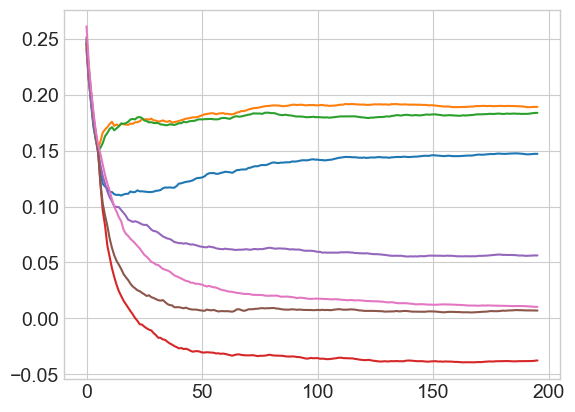

In [34]:
for mo in interactions.keys():
    values = gaussian_filter1d(dispersion_metric_6[mo].mean(axis=0), sigma=0.1)
    plt.plot(values[4:], label=mo)
plt.show()

### Distancia entre preferencias de usuario y usuario representado promedio

In [35]:
dispersion_metric_7 = dict()
for mo in interactions.keys():
    dispersion_metric_7[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            diff_vectors = np.zeros((0, mean_user_attrs.shape[1]), dtype=float)
            for k in range(mean_user_attrs.shape[0]):
                diff = user_prefs[i][k] - mean_user_attrs[k]
                diff_vectors = np.append(diff_vectors, [diff], axis=0)
            distances = np.linalg.norm(diff_vectors, axis=1)
            re.append(distances.mean())
        dispersion_metric_7[mo].append(re)
    dispersion_metric_7[mo] = np.array(dispersion_metric_7[mo])

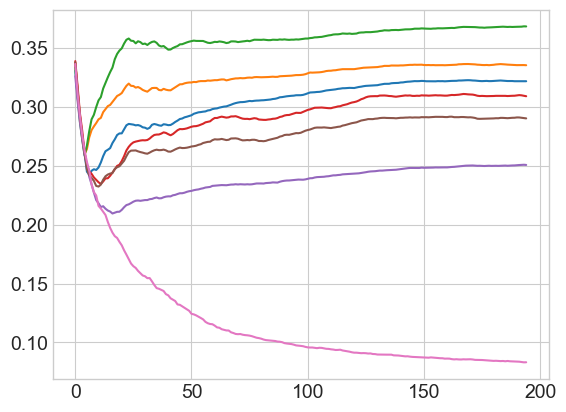

In [36]:
for mo in interactions.keys():
    values = gaussian_filter1d((dispersion_metric_7[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], label=mo)
plt.show()

### Similaridad coseno entre preferencias de usuario y usuario representado promedio

In [37]:
dispersion_metric_7_1 = dict()
for mo in interactions.keys():
    dispersion_metric_7_1[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            consines = cosine_similarity(user_prefs[i], mean_user_attrs).diagonal()
            re.append(consines.mean())
        dispersion_metric_7_1[mo].append(re)
    dispersion_metric_7_1[mo] = np.array(dispersion_metric_7_1[mo])

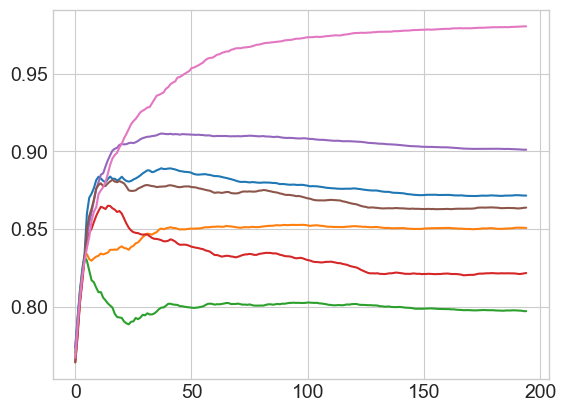

In [38]:
for mo in interactions.keys():
    values = gaussian_filter1d((dispersion_metric_7_1[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], label=mo)
plt.show()

### Otro meme que no recuerdo

In [39]:
dispersion_metric_8 = dict()
for mo in interactions.keys():
    dispersion_metric_8[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        user_iter_attrs_ideal = item_attrs[i].T[interactions['ideal'][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            mean_user_attrs_ideal = user_iter_attrs_ideal[:,:(j+1)].mean(axis=1)
            diff_vectors = np.zeros((0, mean_user_attrs.shape[1]), dtype=float)
            ideal_diff_vectors = np.zeros((0, mean_user_attrs.shape[1]), dtype=float)
            nearest_users = get_sim_users_pairs(mean_user_attrs)
            for p in nearest_users:
                diff = mean_user_attrs[p[0]] - mean_user_attrs[p[1]]
                ideal_diff = mean_user_attrs_ideal[p[0]] - mean_user_attrs_ideal[p[1]]
                diff_vectors = np.append(diff_vectors, [diff], axis=0)
                ideal_diff_vectors = np.append(ideal_diff_vectors, [ideal_diff], axis=0)
            distances = np.linalg.norm(diff_vectors, axis=1) - np.linalg.norm(ideal_diff_vectors, axis=1)
            re.append(distances.mean())
        dispersion_metric_8[mo].append(re)
    dispersion_metric_8[mo] = np.array(dispersion_metric_8[mo])

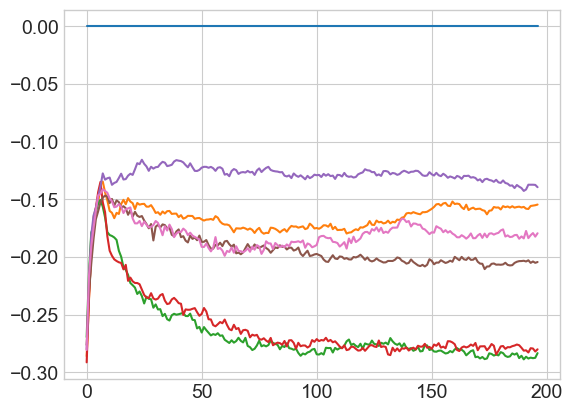

In [40]:
for mo in interactions.keys():
    values = gaussian_filter1d((dispersion_metric_8[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[3:], label=mo)
plt.show()

# Epifanía

## New Inter-User Dispersion

Esta métrica no es más que la root square mean deviation de todos los centroides de los usuarios con respecto al centroide de todos los centroides. En otras palabras:

$$InterDiv= \sqrt{\frac{\sum_{u_j\in U}{||\bar{u}_{j} - \bar{\bar{u}}||^2}}{|U|}}$$

In [10]:
dispersion_metric_9 = dict()
for mo in interactions.keys():
    dispersion_metric_9[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            user_mean = mean_user_attrs.mean(axis=0)
            distances = np.linalg.norm(mean_user_attrs - user_mean, axis=1)
            variance = ((distances**2).sum())/distances.shape[0]
            re.append(variance**0.5)
        dispersion_metric_9[mo].append(re)
    dispersion_metric_9[mo] = np.array(dispersion_metric_9[mo])

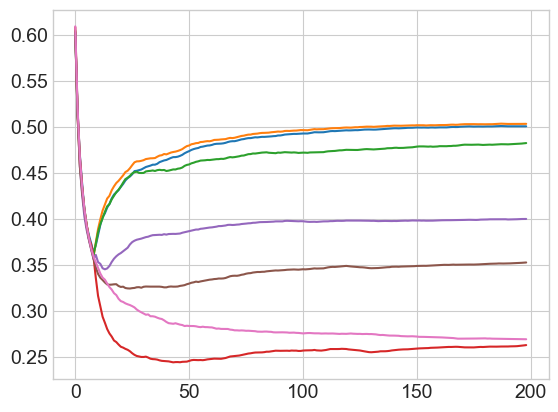

In [11]:
for mo in interactions.keys():
    values = gaussian_filter1d((dispersion_metric_9[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[1:], label=mo)
plt.show()

## New Intra-User Dispersion

Aquí la ecuación es:
$$IntraD = \frac{1}{|U|}\sum_{u_j\in U}\sqrt{\frac{\sum_{i^{j}_k\in I(u_j)}{||i^{j}_k - \bar{u}_j||^2}}{|I(u_j)|}}$$

In [12]:
dispersion_metric_10 = dict()
for mo in interactions.keys():
    dispersion_metric_10[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            diff_vectors = np.array([user_iter_attrs[k,:(j+1)] - mean_user_attrs[k] for k in range(user_iter_attrs.shape[0])])
            distances = np.linalg.norm(diff_vectors, axis=2)
            variances = ((distances**2).sum(axis=1))/distances.shape[1]
            re.append((variances**0.5).mean())
        dispersion_metric_10[mo].append(re)
    dispersion_metric_10[mo] = np.array(dispersion_metric_10[mo])

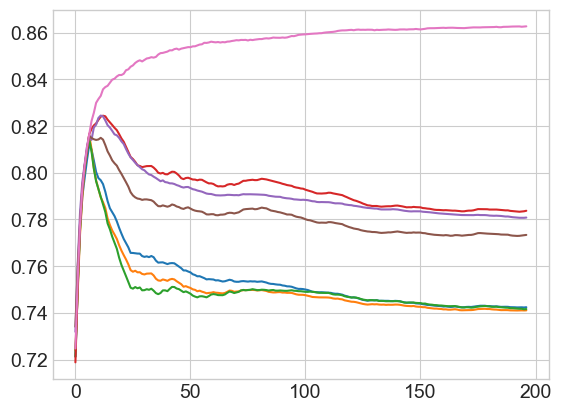

In [13]:
for mo in interactions.keys():
    values = gaussian_filter1d((dispersion_metric_10[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[3:], label=mo)
plt.show()

De estas dos ecuaciones tenemos que:
$$FBE = \frac{InterD}{IntraD} \quad Homog = \frac{1}{InterD^2 + IntraD^2}$$

In [14]:
fbe_1 = dict()
homog_1 = dict()
for mo in interactions.keys():
    fbe_1[mo] = []
    homog_1[mo] = []
    for i in range(interactions[mo].shape[0]):
        fbe_1[mo].append(dispersion_metric_9[mo][i] / dispersion_metric_10[mo][i])
        homog_1[mo].append(1. / (dispersion_metric_9[mo][i]**2 + dispersion_metric_10[mo][i]**2))
    fbe_1[mo] = np.array(fbe_1[mo])
    homog_1[mo] = np.array(homog_1[mo])

In [15]:
ideal_fbe_1 = fbe_1['ideal']
fbe_1_relative = {mo: fbe_1[mo] - ideal_fbe_1 for mo in fbe_1.keys()}
ideal_homog_1 = homog_1['ideal']
homog_1_relative = {mo: homog_1[mo] - ideal_homog_1 for mo in homog_1.keys()}

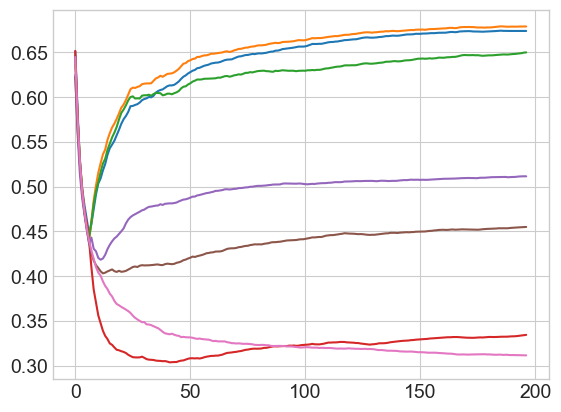

In [16]:
for mo in interactions.keys():
    values = gaussian_filter1d((fbe_1[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[3:], label=mo)
plt.show()

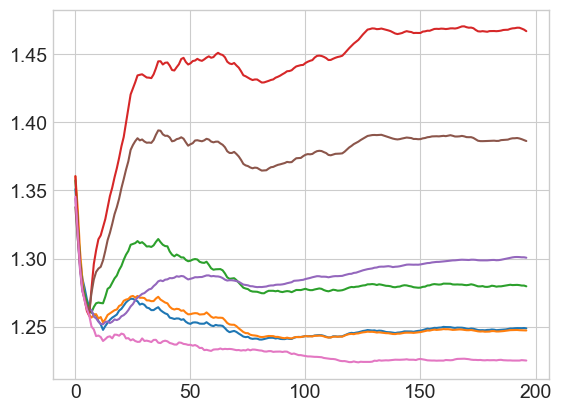

In [17]:
for mo in interactions.keys():
    values = gaussian_filter1d((homog_1[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[3:], label=mo)
plt.show()

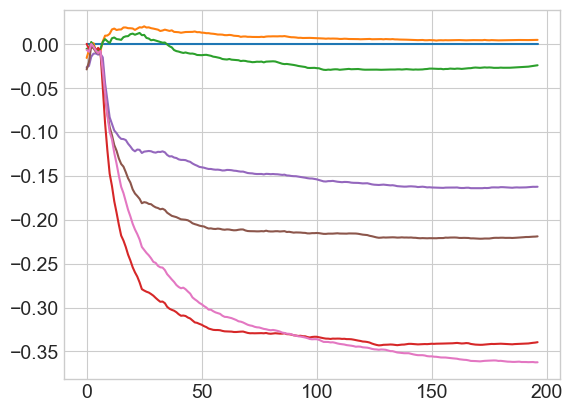

In [18]:
for mo in interactions.keys():
    values = gaussian_filter1d((fbe_1_relative[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[3:], label=mo)
plt.show()

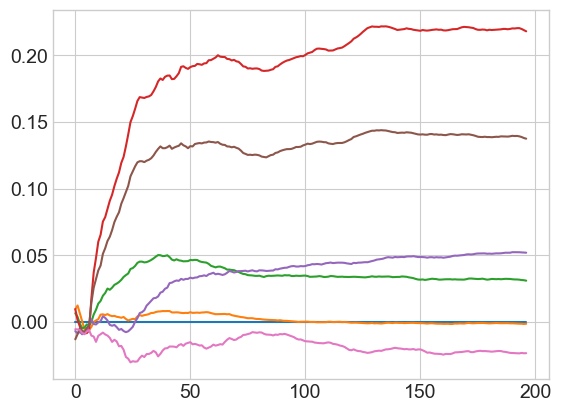

In [19]:
for mo in interactions.keys():
    values = gaussian_filter1d((homog_1_relative[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[3:], label=mo)
plt.show()

# Inter e Intra usando similaridad coseno

In [20]:
dispersion_metric_9_1 = dict()
for mo in interactions.keys():
    dispersion_metric_9_1[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            user_mean = mean_user_attrs.mean(axis=0)
            user_mean_reshaped = np.tile(user_mean, mean_user_attrs.shape[0]).reshape((-1, user_mean.shape[0]))
            cosines = cosine_similarity(mean_user_attrs, user_mean_reshaped)[:,0]
            variance = ((cosines**2).sum())/cosines.shape[0]
            re.append(variance**0.5)
        dispersion_metric_9_1[mo].append(re)
    dispersion_metric_9_1[mo] = np.array(dispersion_metric_9_1[mo])

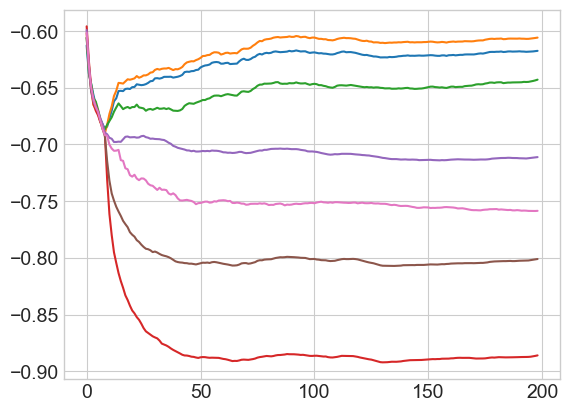

In [21]:
for mo in interactions.keys():
    values = gaussian_filter1d((-dispersion_metric_9_1[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[1:], label=mo)
plt.show()

In [22]:
dispersion_metric_10_1 = dict()
for mo in interactions.keys():
    dispersion_metric_10_1[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            consines = np.array([cosine_similarity(user_iter_attrs[k,:(j+1)], np.tile(mean_user_attrs[k], j+1).reshape((-1, mean_user_attrs[k].shape[0])))[:,0] for k in range(user_iter_attrs.shape[0])])
            variances = ((consines**2).sum(axis=1))/consines.shape[1]
            re.append((variances**0.5).mean())
        dispersion_metric_10_1[mo].append(re)
    dispersion_metric_10_1[mo] = np.array(dispersion_metric_10_1[mo])

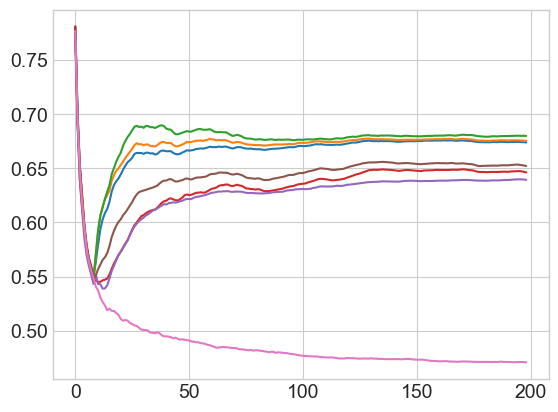

In [23]:
for mo in interactions.keys():
    values = gaussian_filter1d((dispersion_metric_10_1[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[1:], label=mo)
plt.show()

In [24]:
fbe_2 = dict()
homog_2 = dict()
for mo in interactions.keys():
    fbe_2[mo] = []
    homog_2[mo] = []
    for i in range(interactions[mo].shape[0]):
        fbe_2[mo].append(dispersion_metric_10_1[mo][i] / dispersion_metric_9_1[mo][i])
        homog_2[mo].append(dispersion_metric_10_1[mo][i]**2 + dispersion_metric_9_1[mo][i]**2)
    fbe_2[mo] = np.array(fbe_2[mo])
    homog_2[mo] = np.array(homog_2[mo])

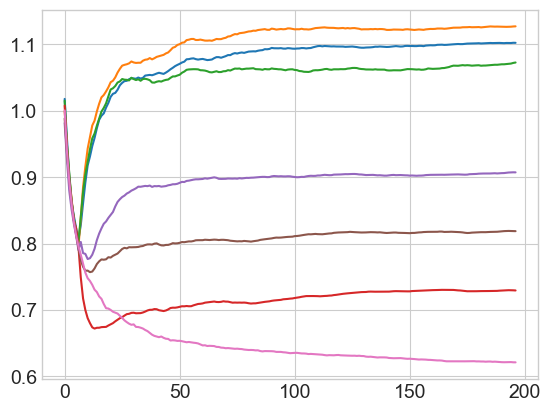

In [25]:
for mo in interactions.keys():
    values = gaussian_filter1d((fbe_2[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[3:], label=mo)
plt.show()

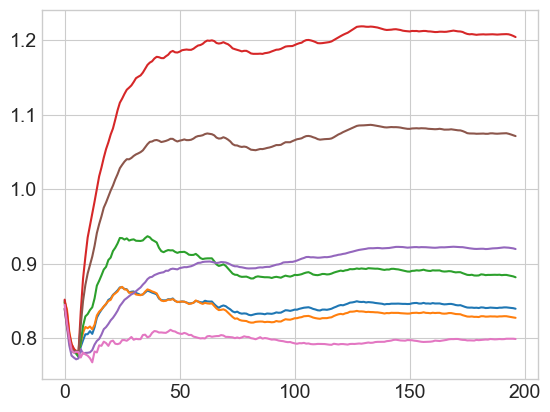

In [26]:
for mo in interactions.keys():
    values = gaussian_filter1d((homog_2[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[3:], label=mo)
plt.show()

Los resultados son basically muy similares sin importar si se usa distancia euclideana o similaridad coseno para calcular diversidades.

# Homogenización entre pares de usuarios

### Varianza general de items de ambos usuarios juntos

In [27]:
dispersion_metric_11 = dict()
for mo in interactions.keys():
    dispersion_metric_11[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        user_iter_attrs_ideal = item_attrs[i].T[interactions['ideal'][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            ideal_mean_user_attrs = user_iter_attrs_ideal[:,:(j+1)].mean(axis=1)
            diffs = []
            nearest_users = get_sim_users_pairs(mean_user_attrs)
            for p in nearest_users:
                pair_items = np.concatenate([user_iter_attrs[p[0],:(j+1)], user_iter_attrs[p[1],:(j+1)]])
                mean_pair_items = pair_items.mean(axis=0)
                distances = np.linalg.norm(pair_items - mean_pair_items, axis=1)
                variance = ((distances**2).sum())/distances.shape[0]

                ideal_pair_items = np.concatenate([user_iter_attrs_ideal[p[0],:(j+1)], user_iter_attrs_ideal[p[1],:(j+1)]])
                ideal_mean_pair_items = ideal_pair_items.mean(axis=0)
                ideal_distances = np.linalg.norm(ideal_pair_items - ideal_mean_pair_items, axis=1)
                ideal_variance = ((ideal_distances**2).sum())/ideal_distances.shape[0]

                diffs.append(ideal_variance**0.5 - variance**0.5)
            re.append(np.array(diffs).mean())
        dispersion_metric_11[mo].append(re)
    dispersion_metric_11[mo] = np.array(dispersion_metric_11[mo])

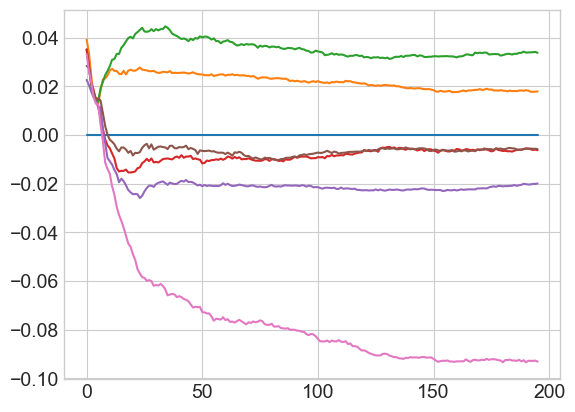

In [28]:
for mo in interactions.keys():
    values = gaussian_filter1d((dispersion_metric_11[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[4:], label=mo)
plt.show()

### Homogenización y fbe calculados como se debe con pares similares

In [29]:
dispersion_metric_12 = dict()
for mo in interactions.keys():
    dispersion_metric_12[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        user_iter_attrs_ideal = item_attrs[i].T[interactions['ideal'][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            ideal_mean_user_attrs = user_iter_attrs_ideal[:,:(j+1)].mean(axis=1)
            diffs = []
            nearest_users = get_sim_users_pairs(mean_user_attrs)
            for p in nearest_users:
                inter_user_div = np.linalg.norm(mean_user_attrs[p[0]] - mean_user_attrs[p[1]])/2
                distances_0 = np.linalg.norm(user_iter_attrs[p[0],:(j+1)] - mean_user_attrs[p[0]], axis=1)
                distances_1 = np.linalg.norm(user_iter_attrs[p[1],:(j+1)] - mean_user_attrs[p[1]], axis=1)
                variance_0 = ((distances_0**2).sum())/distances_0.shape[0]
                variance_1 = ((distances_1**2).sum())/distances_1.shape[0]
                intra_user_div = (variance_0**0.5 + variance_1**0.5) / 2

                ideal_inter_user_div = np.linalg.norm(ideal_mean_user_attrs[p[0]] - ideal_mean_user_attrs[p[1]])/2
                ideal_distances_0 = np.linalg.norm(user_iter_attrs_ideal[p[0],:(j+1)] - ideal_mean_user_attrs[p[0]], axis=1)
                ideal_distances_1 = np.linalg.norm(user_iter_attrs_ideal[p[1],:(j+1)] - ideal_mean_user_attrs[p[1]], axis=1)
                ideal_variance_0 = ((ideal_distances_0**2).sum())/ideal_distances_0.shape[0]
                ideal_variance_1 = ((ideal_distances_1**2).sum())/ideal_distances_1.shape[0]
                ideal_intra_user_div = (ideal_variance_0**0.5 + ideal_variance_1**0.5) / 2

                fbe = inter_user_div / intra_user_div
                ideal_fbe = ideal_inter_user_div / ideal_intra_user_div

                homog = 1. / (inter_user_div**2 + intra_user_div**2)
                ideal_homog = 1. / (ideal_inter_user_div**2 + ideal_intra_user_div**2)

                diffs.append(intra_user_div - ideal_intra_user_div)
            re.append(np.array(diffs).mean())
        dispersion_metric_12[mo].append(re)
    dispersion_metric_12[mo] = np.array(dispersion_metric_12[mo])

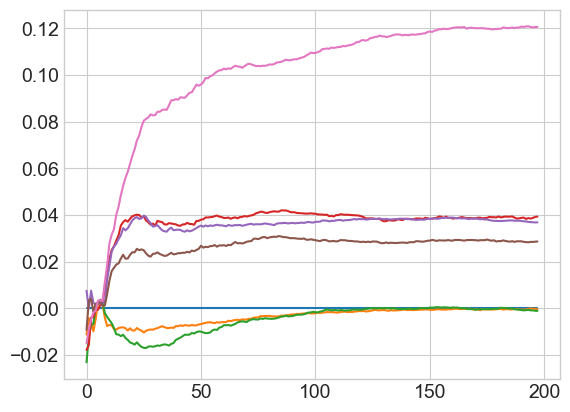

In [30]:
for mo in interactions.keys():
    values = gaussian_filter1d((dispersion_metric_12[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[2:], label=mo)
plt.show()

### Índice de Jaccard promedio entre usuarios aleatorios y entre usuarios similares
Similaridad obtenida por similaridad coseno de cada centroide de cada usuario

In [31]:
mean_Jacc = dict()
for mo in interactions.keys():
    mean_Jacc[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        user_iter_indices = interactions[mo][i]
        user_iter_indices_ideal = interactions['ideal'][i]
        for j in range(user_iter_indices.shape[1]):
            user_jiter_indices = user_iter_indices[:,:(j+1)]
            user_jiter_indices_ideal = user_iter_indices_ideal[:,:(j+1)]
            nearest_users = get_sim_users_pairs(np.zeros((user_iter_attrs.shape[0],2)))
            jacc = 0
            ideal_jacc = 0
            for p in nearest_users:
                setp0 = set(user_jiter_indices[p[0]])
                setp1 = set(user_jiter_indices[p[1]])
                jacc += len(setp0.intersection(setp1)) / len(setp0.union(setp1)) / len(nearest_users)

                ideal_setp0 = set(user_jiter_indices_ideal[p[0]])
                ideal_setp1 = set(user_jiter_indices_ideal[p[1]])
                ideal_jacc += len(ideal_setp0.intersection(ideal_setp1)) / len(ideal_setp0.union(ideal_setp1)) / len(nearest_users)

            re.append(jacc - ideal_jacc)
        mean_Jacc[mo].append(re)
    mean_Jacc[mo] = np.array(mean_Jacc[mo])

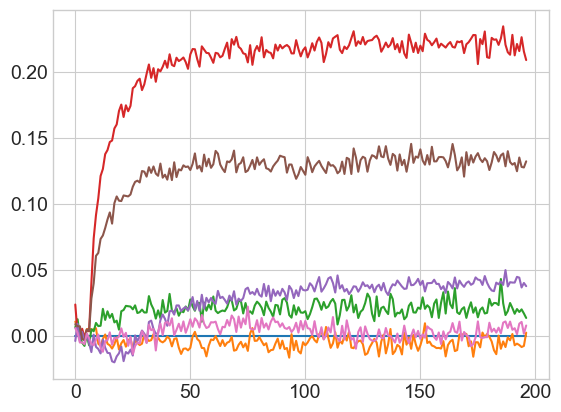

In [32]:
for mo in interactions.keys():
    values = gaussian_filter1d((mean_Jacc[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[3:], label=mo)
plt.show()

In [33]:
mean_J_sim = dict()
for mo in interactions.keys():
    mean_J_sim[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        user_iter_indices = interactions[mo][i]
        user_iter_indices_ideal = interactions['ideal'][i]
        for j in range(user_iter_indices.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            user_jiter_indices = user_iter_indices[:,:(j+1)]
            user_jiter_indices_ideal = user_iter_indices_ideal[:,:(j+1)]
            nearest_users = get_sim_users_pairs(mean_user_attrs)
            jacc = 0
            ideal_jacc = 0
            for p in nearest_users:
                setp0 = set(user_jiter_indices[p[0]])
                setp1 = set(user_jiter_indices[p[1]])
                jacc += len(setp0.intersection(setp1)) / len(setp0.union(setp1)) / len(nearest_users)

                ideal_setp0 = set(user_jiter_indices_ideal[p[0]])
                ideal_setp1 = set(user_jiter_indices_ideal[p[1]])
                ideal_jacc += len(ideal_setp0.intersection(ideal_setp1)) / len(ideal_setp0.union(ideal_setp1)) / len(nearest_users)

            re.append(jacc - ideal_jacc)
        mean_J_sim[mo].append(re)
    mean_J_sim[mo] = np.array(mean_J_sim[mo])

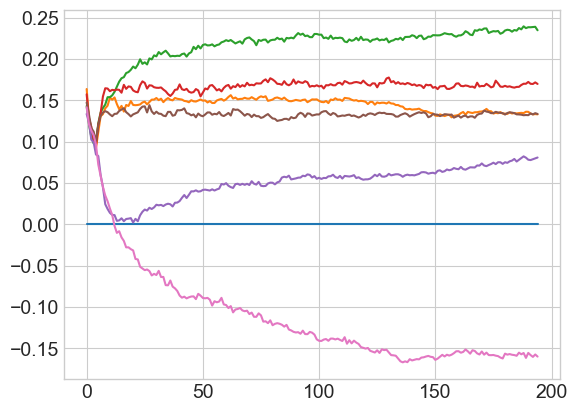

In [34]:
for mo in interactions.keys():
    values = gaussian_filter1d((mean_J_sim[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], label=mo)
plt.show()

In [35]:
dispersion_metric_12_1 = dict()
dispersion_metric_12_2 = dict()
for mo in interactions.keys():
    dispersion_metric_12_1[mo] = []
    dispersion_metric_12_2[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        re2 = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        user_iter_attrs_ideal = item_attrs[i].T[interactions['ideal'][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            ideal_mean_user_attrs = user_iter_attrs_ideal[:,:(j+1)].mean(axis=1)
            diffs = []
            nearest_users = get_sim_users_pairs(mean_user_attrs)
            pair_distance = 0
            ideal_pair_distance = 0
            for p in nearest_users:
                mean_pair_point = (mean_user_attrs[p[0]] + mean_user_attrs[p[1]]) / 2
                ideal_mean_pair_point = (ideal_mean_user_attrs[p[0]] + ideal_mean_user_attrs[p[1]]) / 2
                pair_distance += np.linalg.norm(mean_user_attrs[p[0]] - mean_pair_point)
                ideal_pair_distance += np.linalg.norm(ideal_mean_user_attrs[p[0]] - ideal_mean_pair_point)
            re.append(pair_distance / len(nearest_users))
            re2.append(ideal_pair_distance / len(nearest_users))
        dispersion_metric_12_1[mo].append(re)
        dispersion_metric_12_2[mo].append(re2)
    dispersion_metric_12_1[mo] = np.array(dispersion_metric_12_1[mo])
    dispersion_metric_12_2[mo] = np.array(dispersion_metric_12_2[mo])

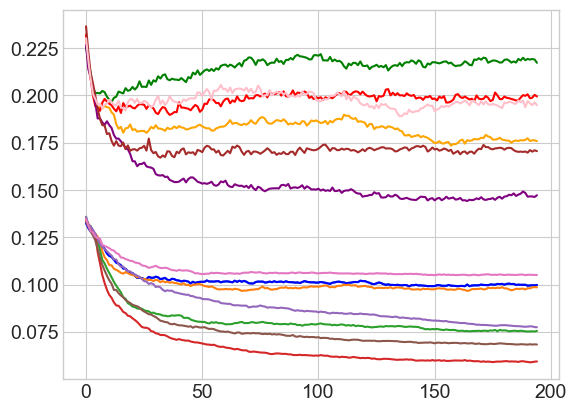

In [36]:
for mo in interactions.keys():
    values = gaussian_filter1d((dispersion_metric_12_1[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    values = gaussian_filter1d((dispersion_metric_12_2[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo][4:])
plt.show()

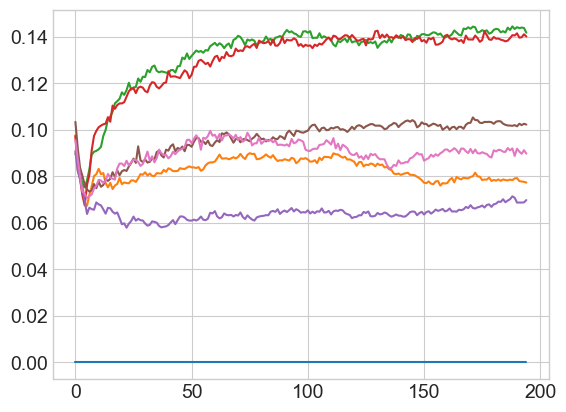

In [37]:
for mo in interactions.keys():
    values = gaussian_filter1d((dispersion_metric_12_2[mo] - dispersion_metric_12_1[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
plt.show()

In [38]:
dispersion_metric_12_3 = dict()
dispersion_metric_12_4 = dict()
for mo in interactions.keys():
    dispersion_metric_12_3[mo] = []
    dispersion_metric_12_4[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        re2 = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        user_iter_attrs_ideal = item_attrs[i].T[interactions['ideal'][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            ideal_mean_user_attrs = user_iter_attrs_ideal[:,:(j+1)].mean(axis=1)
            diffs = []
            nearest_users = get_sim_users_pairs(mean_user_attrs)
            pair_distance = 0
            ideal_pair_distance = 0
            for p in nearest_users:
                mean_pair_point = (mean_user_attrs[p[0]] + mean_user_attrs[p[1]]) / 2
                ideal_mean_pair_point = (ideal_mean_user_attrs[p[0]] + ideal_mean_user_attrs[p[1]]) / 2
                pair_distance += np.linalg.norm(mean_user_attrs[p[0]] - mean_pair_point)*((j+1+2)**0.5)
                ideal_pair_distance += np.linalg.norm(ideal_mean_user_attrs[p[0]] - ideal_mean_pair_point)*((j+1+2)**0.5)
            re.append(pair_distance / len(nearest_users))
            re2.append(ideal_pair_distance / len(nearest_users))
        dispersion_metric_12_3[mo].append(re)
        dispersion_metric_12_4[mo].append(re2)
    dispersion_metric_12_3[mo] = np.array(dispersion_metric_12_3[mo])
    dispersion_metric_12_4[mo] = np.array(dispersion_metric_12_4[mo])

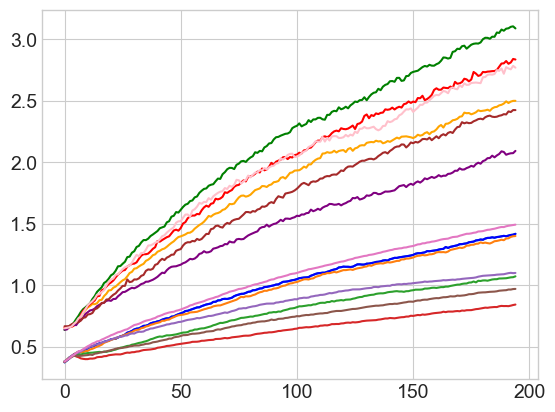

In [39]:
for mo in interactions.keys():
    values = gaussian_filter1d((dispersion_metric_12_3[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    values = gaussian_filter1d((dispersion_metric_12_4[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo][4:])
plt.show()

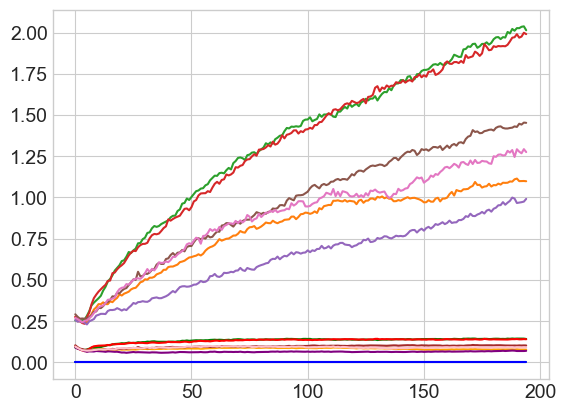

In [40]:
for mo in interactions.keys():
    values = gaussian_filter1d((dispersion_metric_12_4[mo] - dispersion_metric_12_3[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    values = gaussian_filter1d((dispersion_metric_12_2[mo] - dispersion_metric_12_1[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo][4:])
plt.show()

In [41]:
dispersion_metric_12_5 = dict()
dispersion_metric_12_6 = dict()
for mo in interactions.keys():
    dispersion_metric_12_5[mo] = []
    dispersion_metric_12_6[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        re2 = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        user_iter_attrs_ideal = item_attrs[i].T[interactions['ideal'][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            ideal_mean_user_attrs = user_iter_attrs_ideal[:,:(j+1)].mean(axis=1)
            diffs = []
            nearest_users = get_sim_users_pairs(mean_user_attrs)
            pair_variance = 0
            ideal_pair_variance = 0
            for p in nearest_users:
                distances_0 = np.linalg.norm(user_iter_attrs[p[0],:(j+1)] - mean_user_attrs[p[0]], axis=1)
                distances_1 = np.linalg.norm(user_iter_attrs[p[1],:(j+1)] - mean_user_attrs[p[1]], axis=1)
                variance_0 = (distances_0**2).sum()
                variance_1 = (distances_1**2).sum()
                pair_variance += (variance_0 + variance_1) / (j+1-len(p))

                distances_0 = np.linalg.norm(user_iter_attrs_ideal[p[0],:(j+1)] - ideal_mean_user_attrs[p[0]], axis=1)
                distances_1 = np.linalg.norm(user_iter_attrs_ideal[p[1],:(j+1)] - ideal_mean_user_attrs[p[1]], axis=1)
                variance_0 = (distances_0**2).sum()
                variance_1 = (distances_1**2).sum()
                ideal_pair_variance += (variance_0 + variance_1) / (j+1-len(p))
            
            re.append(pair_variance / len(nearest_users))
            re2.append(ideal_pair_variance / len(nearest_users))
        dispersion_metric_12_5[mo].append(re)
        dispersion_metric_12_6[mo].append(re2)
    dispersion_metric_12_5[mo] = np.array(dispersion_metric_12_5[mo])
    dispersion_metric_12_6[mo] = np.array(dispersion_metric_12_6[mo])

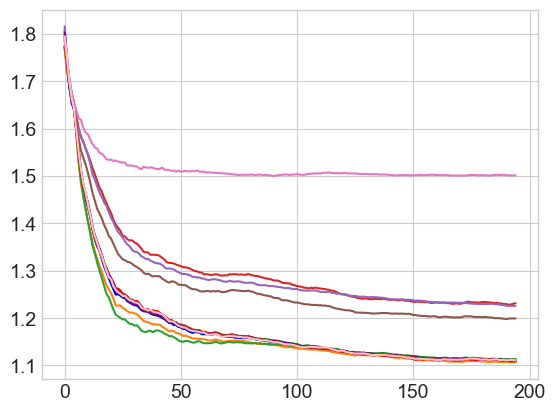

In [42]:
for mo in interactions.keys():
    values = gaussian_filter1d((dispersion_metric_12_5[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    values = gaussian_filter1d((dispersion_metric_12_6[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo][4:])
plt.show()

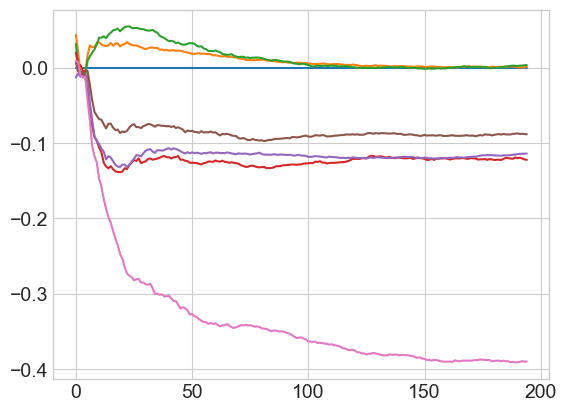

In [43]:
for mo in interactions.keys():
    values = gaussian_filter1d((dispersion_metric_12_6[mo] - dispersion_metric_12_5[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
plt.show()

In [44]:
dispersion_metric_12_7 = dict()
dispersion_metric_12_8 = dict()
for mo in interactions.keys():
    dispersion_metric_12_7[mo] = []
    dispersion_metric_12_8[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        re2 = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        user_iter_attrs_ideal = item_attrs[i].T[interactions['ideal'][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            ideal_mean_user_attrs = user_iter_attrs_ideal[:,:(j+1)].mean(axis=1)
            diffs = []
            nearest_users = get_sim_users_pairs(mean_user_attrs)
            pair_variance = 0
            ideal_pair_variance = 0
            for p in nearest_users:
                distances_0 = np.linalg.norm(user_iter_attrs[p[0],:(j+1)] - mean_user_attrs[p[0]], axis=1)
                distances_1 = np.linalg.norm(user_iter_attrs[p[1],:(j+1)] - mean_user_attrs[p[1]], axis=1)
                variance_0 = ((distances_0**2).sum() / distances_0.shape[0])**0.5
                variance_1 = ((distances_1**2).sum() / distances_1.shape[0])**0.5
                pair_variance += variance_0 + variance_1

                distances_0 = np.linalg.norm(user_iter_attrs_ideal[p[0],:(j+1)] - ideal_mean_user_attrs[p[0]], axis=1)
                distances_1 = np.linalg.norm(user_iter_attrs_ideal[p[1],:(j+1)] - ideal_mean_user_attrs[p[1]], axis=1)
                variance_0 = ((distances_0**2).sum() / distances_0.shape[0])**0.5
                variance_1 = ((distances_1**2).sum() / distances_1.shape[0])**0.5
                ideal_pair_variance += variance_0 + variance_1
            
            re.append(pair_variance / len(nearest_users))
            re2.append(ideal_pair_variance / len(nearest_users))
        dispersion_metric_12_7[mo].append(re)
        dispersion_metric_12_8[mo].append(re2)
    dispersion_metric_12_7[mo] = np.array(dispersion_metric_12_7[mo])
    dispersion_metric_12_8[mo] = np.array(dispersion_metric_12_8[mo])

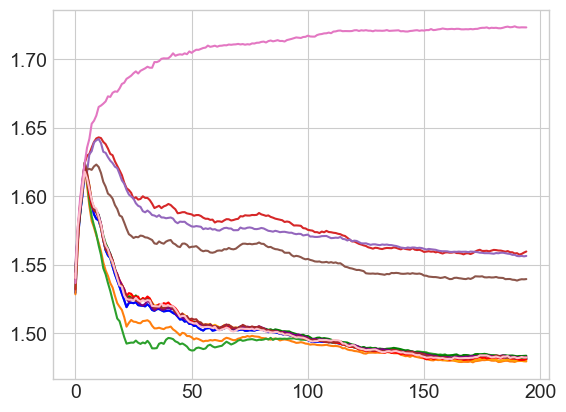

In [45]:
for mo in interactions.keys():
    values = gaussian_filter1d((dispersion_metric_12_7[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    values = gaussian_filter1d((dispersion_metric_12_8[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo][4:])
plt.show()

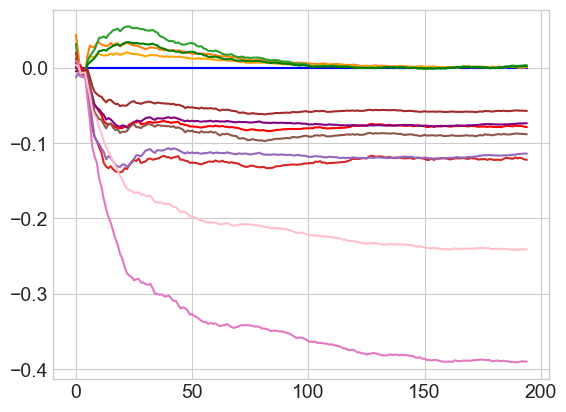

In [46]:
for mo in interactions.keys():
    values = gaussian_filter1d((dispersion_metric_12_6[mo] - dispersion_metric_12_5[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    values = gaussian_filter1d((dispersion_metric_12_8[mo] - dispersion_metric_12_7[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo][4:])
plt.show()

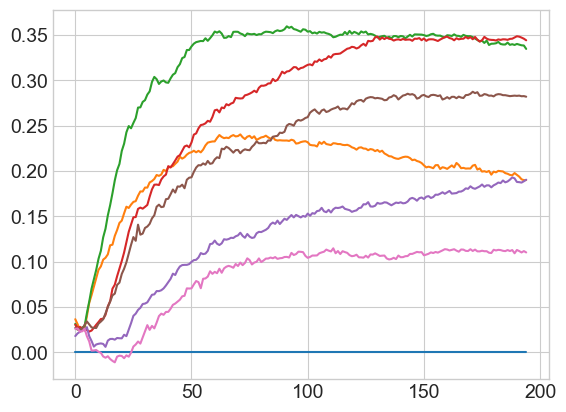

In [47]:
for mo in interactions.keys():
    values = gaussian_filter1d((-(1/ (dispersion_metric_12_4[mo]**2 + dispersion_metric_12_6[mo]**2)) + (1/ (dispersion_metric_12_3[mo]**2 + dispersion_metric_12_5[mo]**2)) ).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
plt.show()

## Método tradicional

In [48]:
dispersion_metric_13 = dict()
for mo in interactions.keys():
    dispersion_metric_13[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        user_iter_attrs_ideal = item_attrs[i].T[interactions['ideal'][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            ideal_mean_user_attrs = user_iter_attrs_ideal[:,:(j+1)].mean(axis=1)
            diffs = []
            nearest_users = get_sim_users_pairs(mean_user_attrs)
            pair_distance = 0
            ideal_pair_distance = 0
            for p in nearest_users:
                pair_distance += np.linalg.norm(mean_user_attrs[p[0]] - mean_user_attrs[p[1]]) / len(nearest_users)
                ideal_pair_distance += np.linalg.norm(ideal_mean_user_attrs[p[0]] - ideal_mean_user_attrs[p[1]]) / len(nearest_users)
            re.append(ideal_pair_distance - pair_distance)
        dispersion_metric_13[mo].append(re)
    dispersion_metric_13[mo] = np.array(dispersion_metric_13[mo])

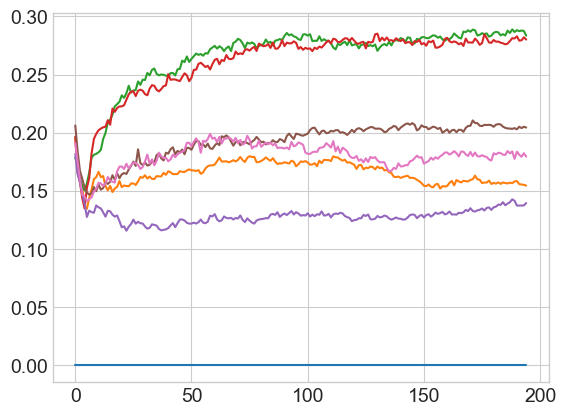

In [49]:
for mo in interactions.keys():
    values = gaussian_filter1d((dispersion_metric_13[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], label=mo)
plt.show()

In [50]:
(dispersion_metric_13["random"]).mean(axis=0)[-1]

0.17947116536466604

In [51]:
dispersion_metric_14 = dict()
for mo in interactions.keys():
    dispersion_metric_14[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        user_iter_attrs_ideal = item_attrs[i].T[interactions['ideal'][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            ideal_mean_user_attrs = user_iter_attrs_ideal[:,:(j+1)].mean(axis=1)
            diffs = []
            nearest_users = get_sim_users_pairs(mean_user_attrs)
            pair_variance = 0
            ideal_pair_variance = 0
            for p in nearest_users:
                distances_0 = np.linalg.norm(user_iter_attrs[p[0],:(j+1)] - mean_user_attrs[p[0]], axis=1)
                distances_1 = np.linalg.norm(user_iter_attrs[p[1],:(j+1)] - mean_user_attrs[p[1]], axis=1)
                variance_0 = ((distances_0**2).sum())/distances_0.shape[0]
                variance_1 = ((distances_1**2).sum())/distances_1.shape[0]
                pair_variance += ((variance_0**0.5 + variance_1**0.5) / 2) / len(nearest_users)

                distances_0 = np.linalg.norm(user_iter_attrs_ideal[p[0],:(j+1)] - ideal_mean_user_attrs[p[0]], axis=1)
                distances_1 = np.linalg.norm(user_iter_attrs_ideal[p[1],:(j+1)] - ideal_mean_user_attrs[p[1]], axis=1)
                variance_0 = ((distances_0**2).sum())/distances_0.shape[0]
                variance_1 = ((distances_1**2).sum())/distances_1.shape[0]
                ideal_pair_variance += ((variance_0**0.5 + variance_1**0.5) / 2) / len(nearest_users)
            re.append(ideal_pair_variance - pair_variance)
        dispersion_metric_14[mo].append(re)
    dispersion_metric_14[mo] = np.array(dispersion_metric_14[mo])

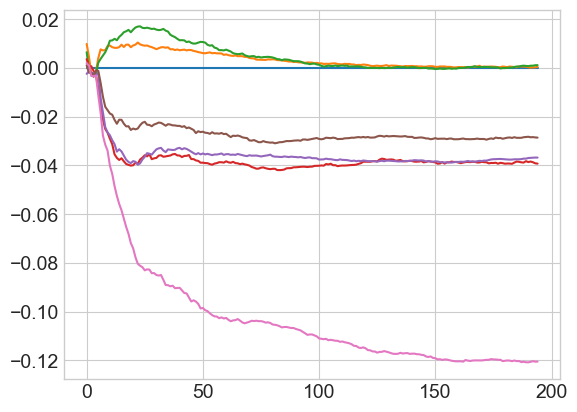

In [52]:
for mo in interactions.keys():
    values = gaussian_filter1d((dispersion_metric_14[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], label=mo)
plt.show()

In [53]:
(dispersion_metric_14["random"]).mean(axis=0)[-1]

-0.12052279461190461

In [54]:
ratio = dict()
for mo in interactions.keys():
    ratio[mo] = []
    for i in range(interactions[mo].shape[0]):
        ratio[mo].append(1./(dispersion_metric_13[mo][i] / (dispersion_metric_11[mo][i] - dispersion_metric_14[mo][i])))
    ratio[mo] = np.array(ratio[mo])


In [55]:
fbe_3 = dict()
homog_3 = dict()
var_in_question = dict()
attempted_Jacc = dict()
searched_var = dict()
found_Jacc = dict()
for mo in interactions.keys():
    fbe_3[mo] = []
    homog_3[mo] = []
    var_in_question[mo] = []
    attempted_Jacc[mo] = []
    searched_var[mo] = []
    found_Jacc[mo] = []
    for i in range(interactions[mo].shape[0]):
        fbe_3[mo].append(dispersion_metric_13[mo][i] / dispersion_metric_14[mo][i])
        homog_3[mo].append(1. / (dispersion_metric_13[mo][i]**2 + dispersion_metric_14[mo][i]**2))
        y_hat = dispersion_metric_13[mo][i]**2 + (2 * dispersion_metric_13[mo][i] * dispersion_metric_14[mo][i])
        var_in_question[mo].append(y_hat - dispersion_metric_14[mo][i]**2)
        attempted_Jacc[mo].append(var_in_question[mo][i] / dispersion_metric_13[mo][i])
        searched_var[mo].append(mean_J_sim[mo][i]*dispersion_metric_13[mo][i])
        found_Jacc[mo].append((var_in_question[mo][i]**2 - (dispersion_metric_11[mo][i] - dispersion_metric_14[mo][i])**2)/(dispersion_metric_13[mo][i]*var_in_question[mo][i]))
    fbe_3[mo] = np.array(fbe_3[mo])
    homog_3[mo] = np.array(homog_3[mo])
    var_in_question[mo] = np.array(var_in_question[mo])
    attempted_Jacc[mo] = np.array(attempted_Jacc[mo])
    searched_var[mo] = np.array(searched_var[mo])
    found_Jacc[mo] = np.array(found_Jacc[mo])

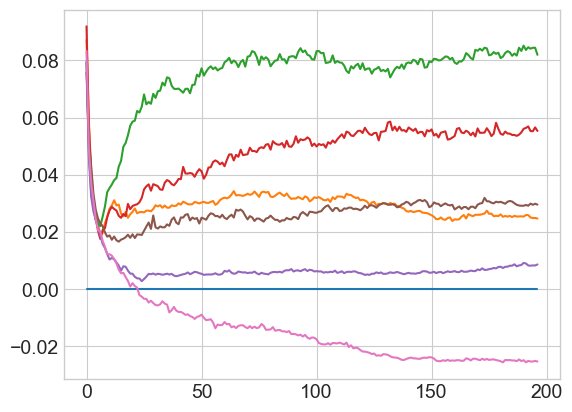

In [56]:
for mo in interactions.keys():
    values = gaussian_filter1d((var_in_question[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[3:], label=mo)
    #plt.ylim((-0.07, 0.1))
plt.show()

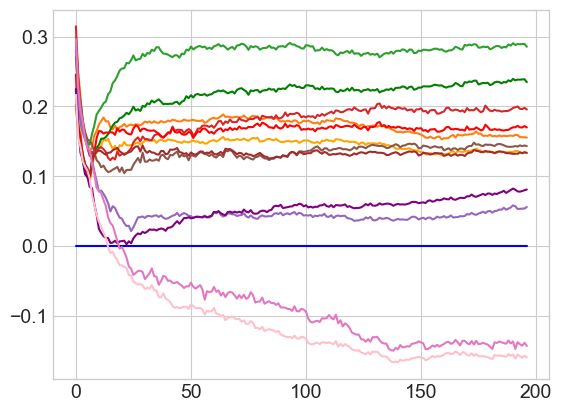

In [57]:
for mo in interactions.keys():
    values = gaussian_filter1d((attempted_Jacc[mo]).mean(axis=0), sigma=0.1)
    values2 = gaussian_filter1d((mean_J_sim[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[3:], color=colors[mo])
    plt.plot(values2[3:], color=colors[mo][4:])
    #plt.ylim((0., 10.))
plt.show()

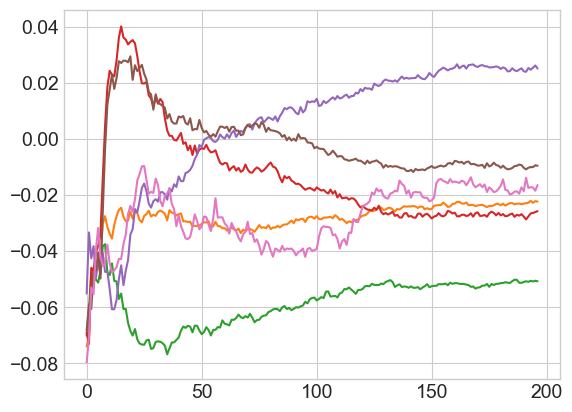

In [58]:
for mo in interactions.keys():
    values = gaussian_filter1d((( (mean_J_sim[mo] - attempted_Jacc[mo]) )).mean(axis=0), sigma=0.1)
    plt.plot(values[3:], label=mo)
    #plt.ylim((0., 2.))
plt.show()

### Ver weas

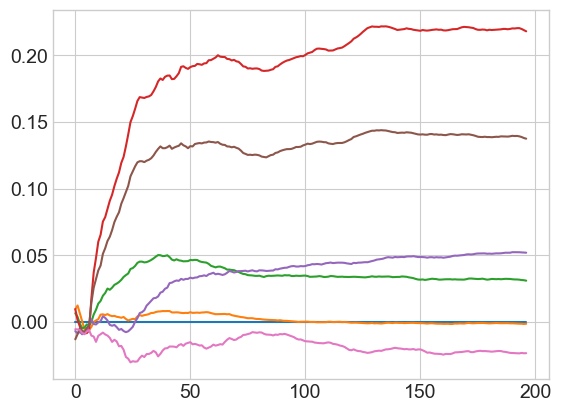

In [59]:
for mo in interactions.keys():
    values = gaussian_filter1d((homog_1_relative[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[3:], label=mo)
plt.show()

### Otras weas

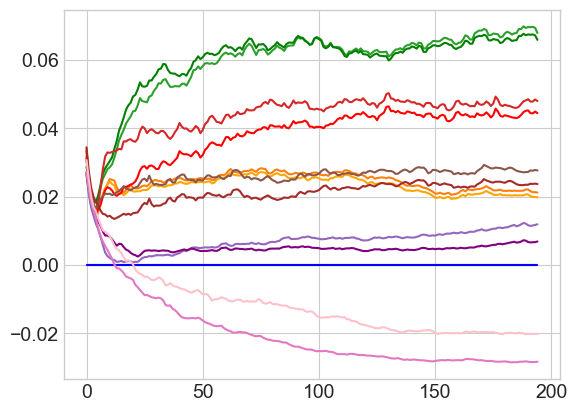

In [60]:
for mo in interactions.keys():
    values = gaussian_filter1d((searched_var[mo]).mean(axis=0), sigma=0.6)
    values2 = gaussian_filter1d((var_in_question[mo]).mean(axis=0), sigma=0.6)
    plt.plot(values[5:], label=mo)
    plt.plot(values2[5:]*0.8, color=colors[mo][4:])
    #plt.ylim((0., 2.))
plt.show()

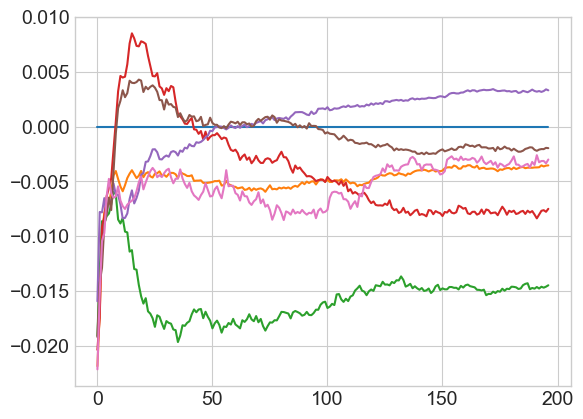

In [61]:
for mo in interactions.keys():
    values = gaussian_filter1d(((searched_var[mo] - var_in_question[mo])).mean(axis=0), sigma=0.1)
    plt.plot(values[3:], label=mo)
    #plt.ylim((0.4, 1.6))
plt.show()

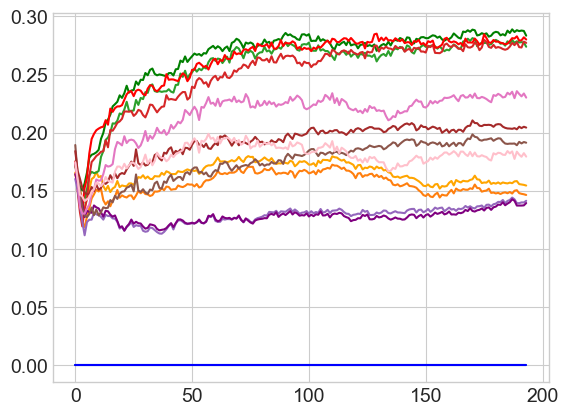

In [62]:
for mo in interactions.keys():
    values = gaussian_filter1d((8.4*((dispersion_metric_11[mo]/1) - (dispersion_metric_14[mo]))).mean(axis=0), sigma=0.1)
    values2 = gaussian_filter1d((dispersion_metric_13[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[6:], color=colors[mo])
    plt.plot(values2[6:], color=colors[mo][4:])
    #plt.ylim((-500, 500))
plt.show()

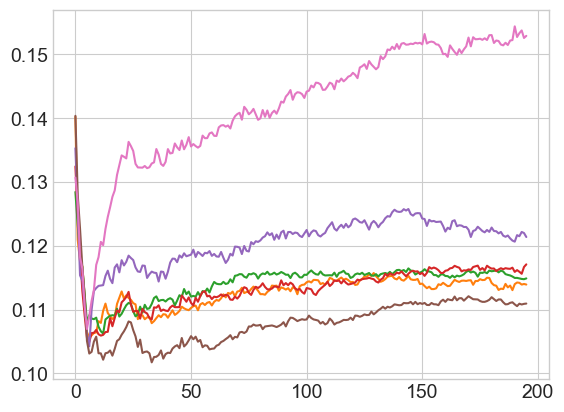

In [63]:
for mo in interactions.keys():
    values = gaussian_filter1d((ratio[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[4:], color=colors[mo])
    #plt.ylim((-500, 500))
plt.show()

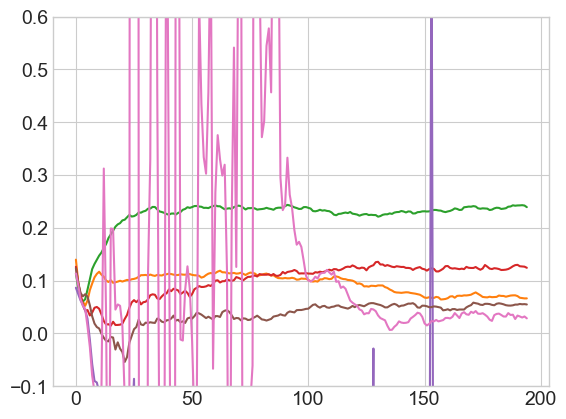

In [64]:
for mo in interactions.keys():
    values = gaussian_filter1d((found_Jacc[mo]).mean(axis=0), sigma=0.6)
    plt.plot(values[5:], label=mo)
    plt.ylim((-0.1, 0.6))
plt.show()

### q es esto de D13/(D11-D14) ?

In [65]:
dispersion_metric_15 = dict()
for mo in interactions.keys():
    dispersion_metric_15[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        user_iter_indices = interactions[mo][i]
        selected_items = np.zeros(0)
        #user_iter_attrs_ideal = item_attrs[i].T[interactions['ideal'][i]]
        for j in range(user_iter_attrs.shape[1]):
            selected_items = np.hstack([selected_items, np.zeros(10)])
            selected_items[user_iter_indices[:,j]] = 1
            re.append(selected_items.shape[0] / selected_items.sum())
        dispersion_metric_15[mo].append(re)
    dispersion_metric_15[mo] = np.array(dispersion_metric_15[mo])

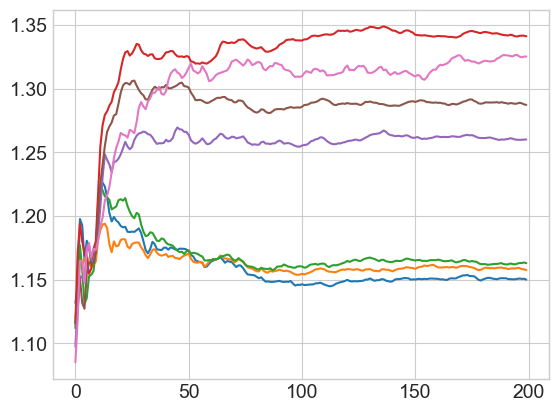

In [66]:
for mo in interactions.keys():
    values = gaussian_filter1d((dispersion_metric_15[mo]).mean(axis=0), sigma=0.6)
    plt.plot(values[0:], color=colors[mo])
    #plt.ylim((-0.1, 0.6))
plt.show()

In [67]:
l = np.zeros(20)
l[interactions["ideal"][0][:,0]] = 1
l

array([0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.])